# Comprehensive Evaluation: OCR vs VLM Benchmark

## Executive Summary

This notebook provides a **comprehensive cross-dataset analysis** of OCR and VLM performance across:

### Part I: Parsing Tasks
- **ICDAR Mini**: Historical handwritten text recognition
- **IAM Mini**: Handwriting recognition  
- **PubLayNet**: Document layout analysis (scientific papers)
- **VOC2007**: Chinese medical lab reports

### Part II: Question Answering Tasks
- **DocVQA Mini**: Document visual question answering
- **InfographicVQA Mini**: Infographic question answering

---

## Metrics Overview

### Parsing Tasks
- **CER** (Character Error Rate): Character-level edit distance (lower is better)
- **WER** (Word Error Rate): Word-level edit distance (lower is better)
- **ANLS** (Average Normalized Levenshtein Similarity): Normalized similarity score (higher is better)

### QA Tasks  
- **ANLS**: Answer similarity metric (higher is better)
- **Exact Match**: Binary correctness (higher is better)

---

## Setup: Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import editdistance
warnings.filterwarnings('ignore')

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


## Load Data from Consolidated CSVs

In [2]:
# Define paths to consolidated CSVs
DATA_BASE = Path("../../2_clean")

# Parsing datasets with their phases
datasets_parsing = {
    'ICDAR_mini': ['phase_1', 'phase_2', 'phase_3a'],
    'IAM_mini': ['phase_1', 'phase_2', 'phase_3'],
    'publaynet_full': ['P-A', 'P-B', 'P-C'],
    'VOC2007': ['phase_1', 'phase_2', 'phase_3a', 'phase_4']
}

# QA datasets with their phases
datasets_qa = {
    'DocVQA_mini': ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b'],
    'InfographicVQA_mini': ['QA1a', 'QA1b', 'QA1c', 'QA2a', 'QA2b', 'QA2c', 'QA3a', 'QA3b', 'QA4a', 'QA4b', 'QA4c']
}

# Check which datasets and phases exist
print("Checking Parsing Task Datasets:")
for name, phases in datasets_parsing.items():
    path = DATA_BASE / name
    if path.exists():
        found_phases = [p for p in phases if (path / f"{p}.csv").exists()]
        print(f"  ✓ {name}: {len(found_phases)}/{len(phases)} phases found")
    else:
        print(f"  ✗ {name}: NOT FOUND")

print("\nChecking QA Task Datasets:")
for name, phases in datasets_qa.items():
    path = DATA_BASE / name
    if path.exists():
        found_phases = [p for p in phases if (path / f"{p}.csv").exists()]
        print(f"  ✓ {name}: {len(found_phases)}/{len(phases)} phases found")
    else:
        print(f"  ✗ {name}: NOT FOUND")

Checking Parsing Task Datasets:
  ✓ ICDAR_mini: 3/3 phases found
  ✓ IAM_mini: 3/3 phases found
  ✓ publaynet_full: 3/3 phases found
  ✓ VOC2007: 4/4 phases found

Checking QA Task Datasets:
  ✓ DocVQA_mini: 8/8 phases found
  ✓ InfographicVQA_mini: 11/11 phases found


## 📊 DATA PREVIEW

Quick look at random samples from both QA and parsing tasks.

In [3]:
# ============================================================================
# DATA PREVIEW: Sample data from QA and Parsing tasks
# ============================================================================

print("="*100)
print("DATA PREVIEW: Cross-Dataset Sample Inspection")
print("="*100)

# Preview a QA dataset
qa_dataset = 'DocVQA_mini'
qa_phase = 'QA1a'
qa_file = DATA_BASE / qa_dataset / f"{qa_phase}.csv"

if qa_file.exists():
    df_qa_preview = pd.read_csv(qa_file)
    random_samples = df_qa_preview.sample(n=min(5, len(df_qa_preview)), random_state=42)
    
    # Get columns to show
    cols_to_show = ['sample_id', 'question', 'ground_truths']
    pred_cols = [col for col in df_qa_preview.columns if col.startswith('prediction_')]
    cols_to_show.extend(pred_cols[:2])  # Show first 2 models
    
    display_df = random_samples[cols_to_show].copy()
    
    # Truncate long strings
    for col in display_df.columns:
        if display_df[col].dtype == 'object':
            display_df[col] = display_df[col].apply(
                lambda x: str(x)[:80] + '...' if pd.notna(x) and len(str(x)) > 80 else x
            )
    
    print(f"\n{'='*100}")
    print(f"QA TASK PREVIEW: {qa_dataset} - {qa_phase}")
    print(f"Showing 5 random samples")
    print(f"{'='*100}\n")
    display(display_df)
    print(f"\nTotal samples: {len(df_qa_preview)}")
else:
    print(f"\n⚠ QA preview file not found: {qa_file}")

# Preview a Parsing dataset
parsing_dataset = 'IAM_mini'
parsing_phase = 'phase_1'
parsing_file = DATA_BASE / parsing_dataset / f"{parsing_phase}.csv"

if parsing_file.exists():
    df_parsing_preview = pd.read_csv(parsing_file)
    random_samples = df_parsing_preview.sample(n=min(5, len(df_parsing_preview)), random_state=42)
    
    # Get columns to show
    cols_to_show = ['sample_id', 'ground_truth']
    pred_cols = [col for col in df_parsing_preview.columns if col.startswith('prediction_')]
    cols_to_show.extend(pred_cols[:2])  # Show first 2 models
    
    display_df = random_samples[cols_to_show].copy()
    
    # Truncate long strings
    for col in display_df.columns:
        if display_df[col].dtype == 'object':
            display_df[col] = display_df[col].apply(
                lambda x: str(x)[:80] + '...' if pd.notna(x) and len(str(x)) > 80 else x
            )
    
    print(f"\n{'='*100}")
    print(f"PARSING TASK PREVIEW: {parsing_dataset} - {parsing_phase}")
    print(f"Showing 5 random samples")
    print(f"{'='*100}\n")
    display(display_df)
    print(f"\nTotal samples: {len(df_parsing_preview)}")
else:
    print(f"\n⚠ Parsing preview file not found: {parsing_file}")

print(f"\n{'='*100}")

DATA PREVIEW: Cross-Dataset Sample Inspection

QA TASK PREVIEW: DocVQA_mini - QA1a
Showing 5 random samples



,sample_id,question,ground_truths,prediction_azure_intelligence__gpt-5-mini,prediction_mistral_document_ai__gpt-5-mini
361,docvqa_mini_0361,In which year National Research Council was or...,"[""1916""]",1916,1916
73,docvqa_mini_0073,What is the name of the department and the loc...,"[""NPT""]",NPT,Department Name and Location: NPT
374,docvqa_mini_0374,What is the date on this check?,"[""August 1, 1974""]","August 1, 1974","August 1, 1974"
155,docvqa_mini_0155,How many references are mentioned?,"[""11""]",11,11
104,docvqa_mini_0104,What is written inside the diagram?,"[""PROTECT""]",Use Pesticides Safely,FOLLOW THE LABEL



Total samples: 500

PARSING TASK PREVIEW: IAM_mini - phase_1
Showing 5 random samples



,sample_id,ground_truth,prediction_azure_intelligence,prediction_mistral_document_ai
361,iam_454_k07-063a,He looked at her. Head thrown back in a pool o...,He looked at her . Heard thrown back in a pool...,He looked at her. Head thrown back in a pool o...
73,iam_094_b01-136,"Unless they do at least that, Dr. Verwoerd wil...","1\nUnless they do at least that , Dr. Verwoerd...","Unless they do at least that, Dr. Verwoerd wil..."
374,iam_480_l04-012,"'Aw, forget it', she said cheerfully. 'I'll st...","' Aw , forget it "" she said cheerfully . "" I'l...","""Aw, forget it"", she said cheerfully. ""I'll st..."
155,iam_187_d04-037,"Then the whole earth will be His Altar. ""And i...","They the whole earth will be His Altar . "" And...","Then the whole earth will be His Altar. ""And i..."
104,iam_129_c06-138,"The plain, sober manner of its style all the m...","The plain , sober manner of its\nStyle\nall th...","The plain, sober manner of its style all the m..."



Total samples: 500



## Helper Functions for Metric Computation

In [4]:
def compute_cer(pred, gt):
    """Compute Character Error Rate."""
    if not gt:
        return 1.0 if pred else 0.0
    return editdistance.eval(pred, gt) / len(gt)

def compute_wer(pred, gt):
    """Compute Word Error Rate."""
    pred_words = pred.split()
    gt_words = gt.split()
    if not gt_words:
        return 1.0 if pred_words else 0.0
    return editdistance.eval(pred_words, gt_words) / len(gt_words)

def extract_models_from_predictions(df, prefix='prediction_'):
    """Extract model names from prediction columns."""
    pred_cols = [col for col in df.columns if col.startswith(prefix)]
    models = [col.replace(prefix, '') for col in pred_cols]
    return models

def compute_parsing_metrics(df, models):
    """Compute CER and WER for parsing tasks from a dataframe."""
    metrics = []
    
    for model in models:
        pred_col = f'prediction_{model}'
        
        if pred_col not in df.columns or 'ground_truth' not in df.columns:
            continue
        
        valid_rows = df[[pred_col, 'ground_truth']].dropna()
        
        if len(valid_rows) == 0:
            continue
        
        cers = []
        wers = []
        
        for _, row in valid_rows.iterrows():
            pred = str(row[pred_col]).strip().lower()
            gt = str(row['ground_truth']).strip().lower()
            
            cers.append(compute_cer(pred, gt))
            wers.append(compute_wer(pred, gt))
        
        metrics.append({
            'model': model,
            'cer_mean': np.mean(cers),
            'wer_mean': np.mean(wers),
            'samples': len(valid_rows)
        })
    
    return pd.DataFrame(metrics)

def aggregate_qa_metrics(df, models):
    """Aggregate QA metrics (ANLS, Exact Match) from a dataframe."""
    metrics = []
    
    for model in models:
        anls_col = f'anls_score_{model}'
        em_col = f'exact_match_{model}'
        
        if anls_col in df.columns and em_col in df.columns:
            metrics.append({
                'model': model,
                'anls': df[anls_col].mean(),
                'exact_match': df[em_col].mean(),
                'samples': df[anls_col].notna().sum()
            })
    
    return pd.DataFrame(metrics)

print("✓ Helper functions defined")

✓ Helper functions defined


## Load Parsing Task Data

In [5]:
# Load all parsing datasets and compute metrics
parsing_results = []

for dataset_name, phases in datasets_parsing.items():
    dataset_path = DATA_BASE / dataset_name
    
    if not dataset_path.exists():
        continue
    
    for phase in phases:
        phase_file = dataset_path / f"{phase}.csv"
        
        if not phase_file.exists():
            continue
        
        df = pd.read_csv(phase_file)
        models = extract_models_from_predictions(df)
        
        if len(models) == 0:
            continue
        
        # Compute metrics for each model
        phase_metrics = compute_parsing_metrics(df, models)
        phase_metrics['dataset'] = dataset_name
        phase_metrics['phase'] = phase
        
        parsing_results.append(phase_metrics)

if parsing_results:
    df_parsing = pd.concat(parsing_results, ignore_index=True)
    print(f"✓ Loaded {len(df_parsing)} parsing task results")
    print(f"  Datasets: {df_parsing['dataset'].nunique()}")
    print(f"  Phases: {df_parsing['phase'].nunique()}")
    print(f"  Models: {df_parsing['model'].nunique()}")
    display(df_parsing.head(10))
else:
    df_parsing = pd.DataFrame()
    print("⚠ No parsing task results found")

✓ Loaded 23 parsing task results
  Datasets: 3
  Phases: 5
  Models: 6


,model,cer_mean,wer_mean,samples,dataset,phase
0,azure_intelligence,0.596467,0.762177,483,ICDAR_mini,phase_1
1,donut,3.739660,4.524862,491,ICDAR_mini,phase_1
2,mistral_document_ai,5.075039,4.202727,491,ICDAR_mini,phase_1
3,gpt-5-mini,2.159056,1.987003,485,ICDAR_mini,phase_2
4,gpt-5-nano,1.990166,1.985166,325,ICDAR_mini,phase_2
5,gpt-5-mini,0.524618,0.676498,467,ICDAR_mini,phase_3a
6,gpt-5-nano,0.495819,0.662813,249,ICDAR_mini,phase_3a
7,azure_intelligence,0.084984,0.291305,500,IAM_mini,phase_1
8,mistral_document_ai,0.027698,0.035952,500,IAM_mini,phase_1
9,claude_sonnet,0.156821,0.206280,500,IAM_mini,phase_2


## Load QA Task Data

In [6]:
# Load all QA datasets and aggregate metrics
qa_results = []

for dataset_name, phases in datasets_qa.items():
    dataset_path = DATA_BASE / dataset_name
    
    if not dataset_path.exists():
        continue
    
    for phase in phases:
        phase_file = dataset_path / f"{phase}.csv"
        
        if not phase_file.exists():
            continue
        
        df = pd.read_csv(phase_file)
        models = extract_models_from_predictions(df)
        
        if len(models) == 0:
            continue
        
        # Aggregate metrics for each model
        phase_metrics = aggregate_qa_metrics(df, models)
        phase_metrics['dataset'] = dataset_name
        phase_metrics['phase'] = phase
        
        qa_results.append(phase_metrics)

if qa_results:
    df_qa = pd.concat(qa_results, ignore_index=True)
    print(f"✓ Loaded {len(df_qa)} QA task results")
    print(f"  Datasets: {df_qa['dataset'].nunique()}")
    print(f"  Phases: {df_qa['phase'].nunique()}")
    print(f"  Models: {df_qa['model'].nunique()}")
    display(df_qa.head(10))
else:
    df_qa = pd.DataFrame()
    print("⚠ No QA task results found")

✓ Loaded 37 QA task results
  Datasets: 2
  Phases: 11
  Models: 7


,model,anls,exact_match,samples,dataset,phase
0,azure_intelligence__gpt-5-mini,0.614528,0.452,500,DocVQA_mini,QA1a
1,mistral_document_ai__gpt-5-mini,0.606261,0.450,500,DocVQA_mini,QA1a
2,azure_intelligence__gpt-5-mini,0.828848,0.734,500,DocVQA_mini,QA1b
3,mistral_document_ai__gpt-5-mini,0.789620,0.714,500,DocVQA_mini,QA1b
4,azure_intelligence__gpt-5-mini,0.726391,0.560,500,DocVQA_mini,QA1c
5,mistral_document_ai__gpt-5-mini,0.691351,0.530,500,DocVQA_mini,QA1c
6,gpt-5-mini__gpt-5-mini,0.613482,0.442,500,DocVQA_mini,QA2a
7,gpt-5-nano__gpt-5-mini,0.345776,0.250,500,DocVQA_mini,QA2a
8,gpt-5-mini__gpt-5-mini,0.864807,0.776,500,DocVQA_mini,QA2b
9,gpt-5-nano__gpt-5-mini,0.411488,0.370,500,DocVQA_mini,QA2b


---

# Part I: Parsing Tasks

Analyzing **CER** and **WER** across:
- ICDAR Mini
- IAM Mini  
- PubLayNet
- VOC2007

---

## 1. Character Error Rate (CER) - Parsing Tasks

### 1.1 CER by Dataset

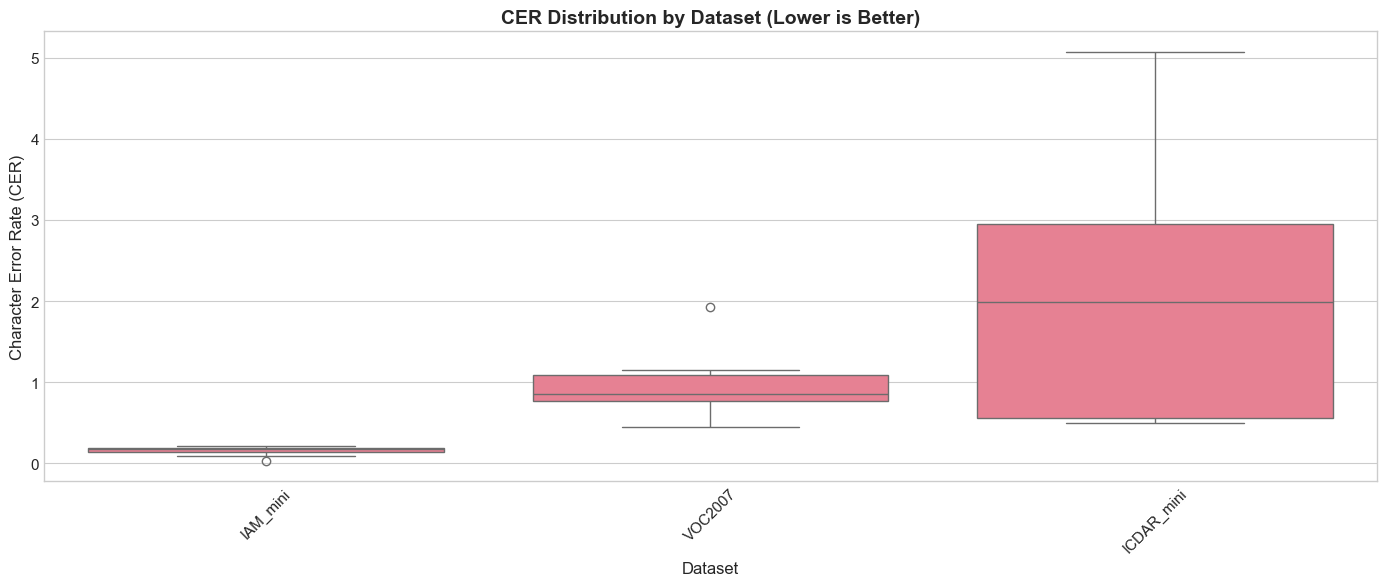


CER Summary by Dataset:


,mean,median,std,min,max
dataset,,,,,
IAM_mini,0.1518,0.1754,0.0628,0.0277,0.2070
ICDAR_mini,2.0830,1.9902,1.7734,0.4958,5.0750
VOC2007,0.9742,0.8510,0.4392,0.4507,1.9223


In [7]:
if not df_parsing.empty and 'cer_mean' in df_parsing.columns:
    # CER by dataset
    fig, ax = plt.subplots(figsize=(14, 6))
    
    dataset_order = df_parsing.groupby('dataset')['cer_mean'].mean().sort_values().index
    
    sns.boxplot(data=df_parsing, x='dataset', y='cer_mean', order=dataset_order, ax=ax)
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel('Character Error Rate (CER)', fontsize=12)
    ax.set_title('CER Distribution by Dataset (Lower is Better)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    summary_cer = df_parsing.groupby('dataset')['cer_mean'].agg(['mean', 'median', 'std', 'min', 'max']).round(4)
    print("\nCER Summary by Dataset:")
    display(summary_cer)
else:
    print("No CER data available")

### 1.2 CER by Model (Across All Parsing Datasets)

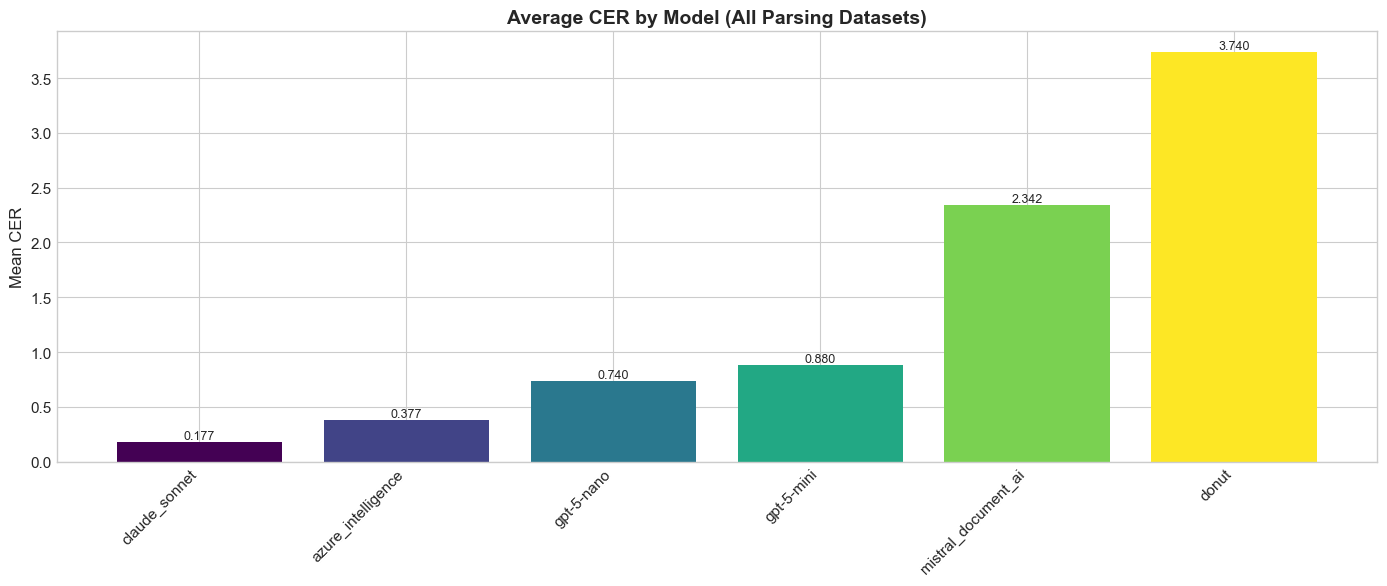

In [8]:
if not df_parsing.empty and 'cer_mean' in df_parsing.columns:
    # CER by model
    fig, ax = plt.subplots(figsize=(14, 6))
    
    model_cer = df_parsing.groupby('model')['cer_mean'].mean().sort_values()
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(model_cer)))
    bars = ax.bar(range(len(model_cer)), model_cer.values, color=colors)
    ax.set_xticks(range(len(model_cer)))
    ax.set_xticklabels(model_cer.index, rotation=45, ha='right')
    ax.set_ylabel('Mean CER', fontsize=12)
    ax.set_title('Average CER by Model (All Parsing Datasets)', fontsize=14, fontweight='bold')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("No CER data available")

### 1.3 CER Comparison: Best vs Worst Models per Dataset

In [9]:
if not df_parsing.empty and 'cer_mean' in df_parsing.columns:
    # Best and worst per dataset
    for dataset in df_parsing['dataset'].unique():
        dataset_data = df_parsing[df_parsing['dataset'] == dataset]
        
        if len(dataset_data) > 0:
            best = dataset_data.loc[dataset_data['cer_mean'].idxmin()]
            worst = dataset_data.loc[dataset_data['cer_mean'].idxmax()]
            
            print(f"\n{dataset}:")
            print(f"  Best:  {best['model']} (Phase {best['phase']}) - CER: {best['cer_mean']:.4f}")
            print(f"  Worst: {worst['model']} (Phase {worst['phase']}) - CER: {worst['cer_mean']:.4f}")
            print(f"  Difference: {(worst['cer_mean'] - best['cer_mean']):.4f}")
else:
    print("No CER data available")


ICDAR_mini:
  Best:  gpt-5-nano (Phase phase_3a) - CER: 0.4958
  Worst: mistral_document_ai (Phase phase_1) - CER: 5.0750
  Difference: 4.5792

IAM_mini:
  Best:  mistral_document_ai (Phase phase_1) - CER: 0.0277
  Worst: gpt-5-nano (Phase phase_2) - CER: 0.2070
  Difference: 0.1793

VOC2007:
  Best:  azure_intelligence (Phase phase_1) - CER: 0.4507
  Worst: mistral_document_ai (Phase phase_1) - CER: 1.9223
  Difference: 1.4715


## 2. Word Error Rate (WER) - Parsing Tasks

### 2.1 WER by Dataset

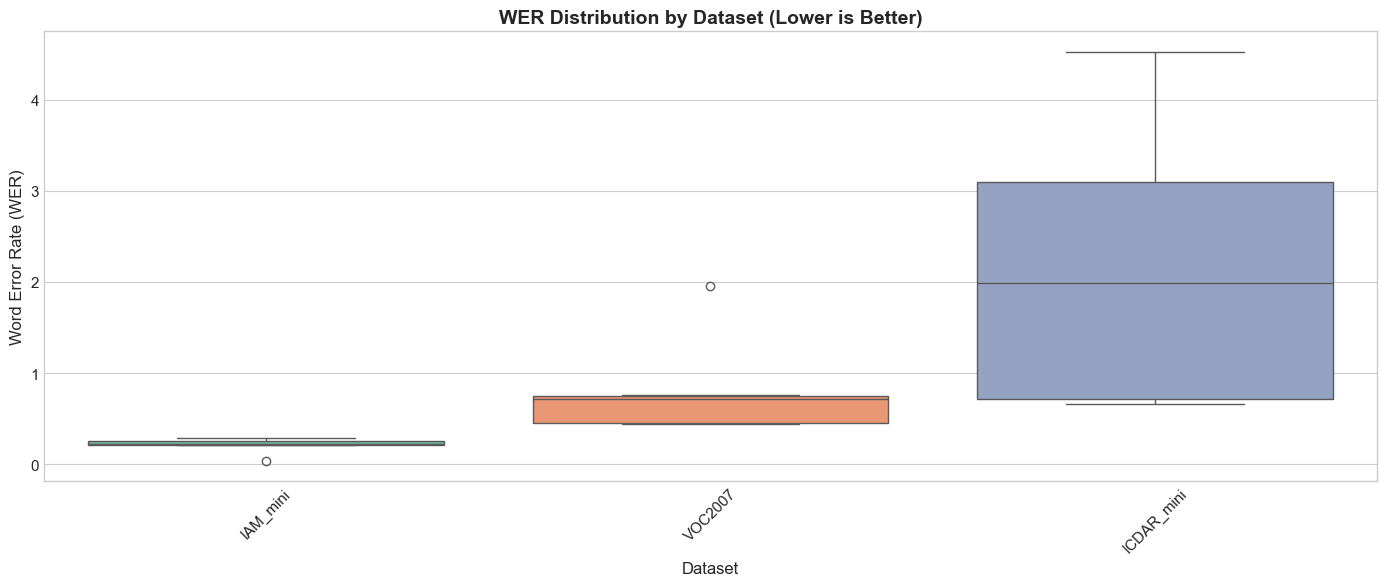


WER Summary by Dataset:


,mean,median,std,min,max
dataset,,,,,
IAM_mini,0.2138,0.2261,0.0778,0.0360,0.2913
ICDAR_mini,2.1145,1.9852,1.6436,0.6628,4.5249
VOC2007,0.7780,0.7110,0.4981,0.4424,1.9597


In [10]:
if not df_parsing.empty and 'wer_mean' in df_parsing.columns:
    # WER by dataset
    fig, ax = plt.subplots(figsize=(14, 6))
    
    dataset_order = df_parsing.groupby('dataset')['wer_mean'].mean().sort_values().index
    
    sns.boxplot(data=df_parsing, x='dataset', y='wer_mean', order=dataset_order, ax=ax, palette='Set2')
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel('Word Error Rate (WER)', fontsize=12)
    ax.set_title('WER Distribution by Dataset (Lower is Better)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    summary_wer = df_parsing.groupby('dataset')['wer_mean'].agg(['mean', 'median', 'std', 'min', 'max']).round(4)
    print("\nWER Summary by Dataset:")
    display(summary_wer)
else:
    print("No WER data available")

### 2.2 WER by Model (Across All Parsing Datasets)

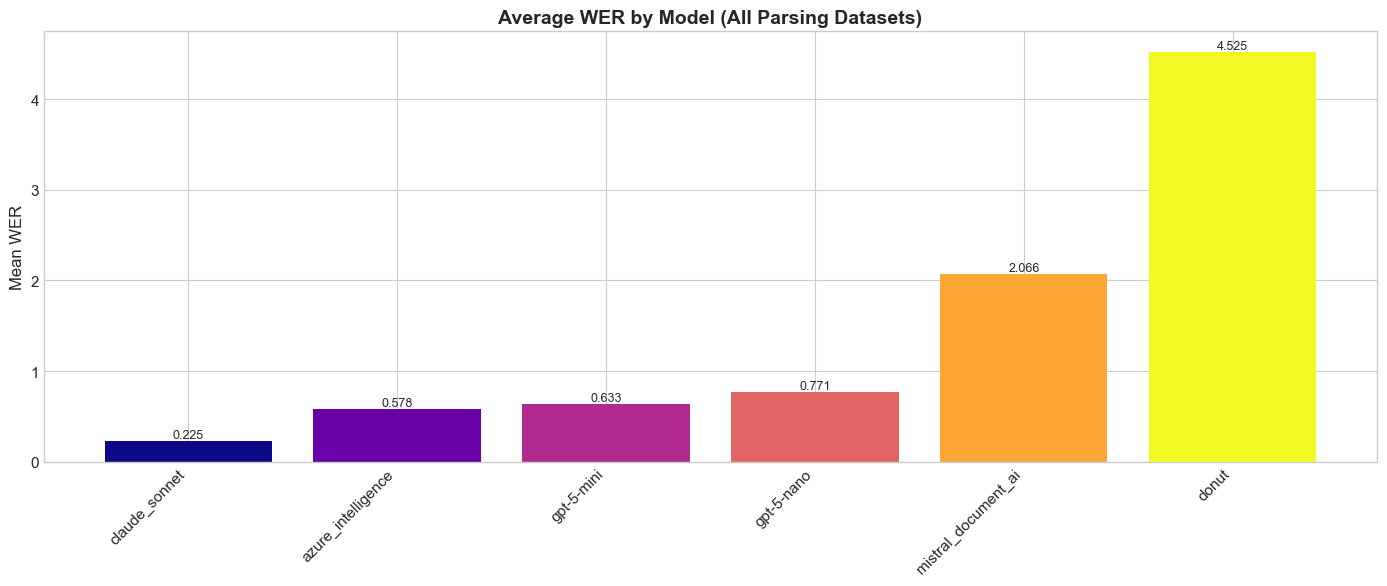

In [11]:
if not df_parsing.empty and 'wer_mean' in df_parsing.columns:
    # WER by model
    fig, ax = plt.subplots(figsize=(14, 6))
    
    model_wer = df_parsing.groupby('model')['wer_mean'].mean().sort_values()
    
    colors = plt.cm.plasma(np.linspace(0, 1, len(model_wer)))
    bars = ax.bar(range(len(model_wer)), model_wer.values, color=colors)
    ax.set_xticks(range(len(model_wer)))
    ax.set_xticklabels(model_wer.index, rotation=45, ha='right')
    ax.set_ylabel('Mean WER', fontsize=12)
    ax.set_title('Average WER by Model (All Parsing Datasets)', fontsize=14, fontweight='bold')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("No WER data available")

## 3. Cross-Metric Comparison - Parsing Tasks

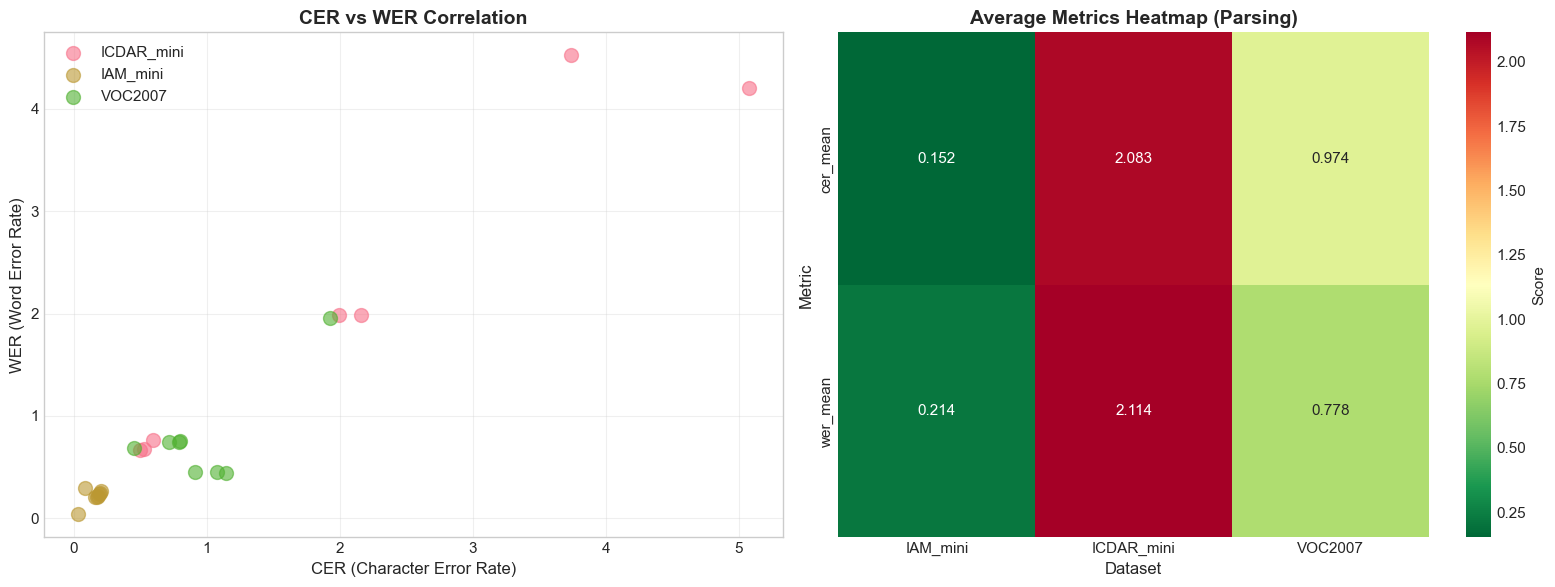

In [12]:
if not df_parsing.empty:
    # CER vs WER correlation
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter: CER vs WER
    ax1 = axes[0]
    for dataset in df_parsing['dataset'].unique():
        data = df_parsing[df_parsing['dataset'] == dataset]
        ax1.scatter(data['cer_mean'], data['wer_mean'], label=dataset, alpha=0.6, s=100)
    
    ax1.set_xlabel('CER (Character Error Rate)', fontsize=12)
    ax1.set_ylabel('WER (Word Error Rate)', fontsize=12)
    ax1.set_title('CER vs WER Correlation', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Heatmap: Average metrics by dataset
    ax2 = axes[1]
    pivot_data = df_parsing.groupby('dataset')[['cer_mean', 'wer_mean']].mean()
    
    sns.heatmap(pivot_data.T, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax2, cbar_kws={'label': 'Score'})
    ax2.set_title('Average Metrics Heatmap (Parsing)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Dataset', fontsize=12)
    ax2.set_ylabel('Metric', fontsize=12)
    
    plt.tight_layout()
    plt.show()
else:
    print("No parsing data available")

---

# Part II: Question Answering Tasks

Analyzing **ANLS** and **Exact Match** across:
- DocVQA Mini
- InfographicVQA Mini

---

## 4. ANLS - QA Tasks

### 4.1 ANLS by Dataset (QA)

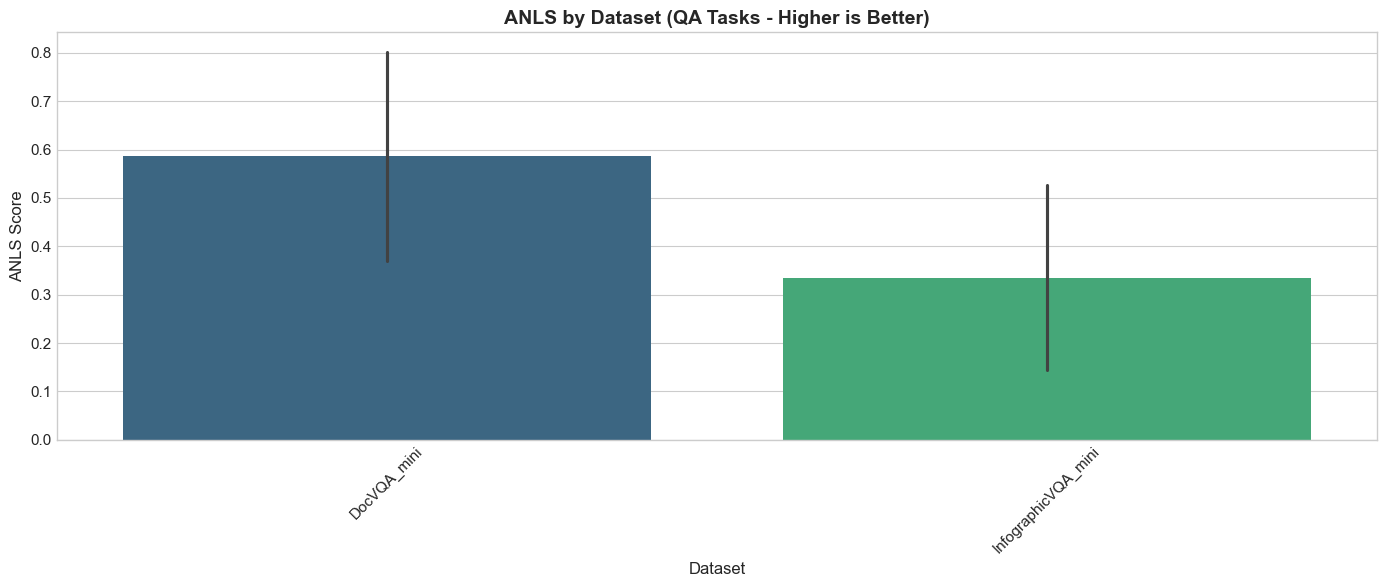


ANLS Summary by Dataset (QA):


,mean,median,std,min,max
dataset,,,,,
DocVQA_mini,0.5858,0.6234,0.2166,0.1231,0.8648
InfographicVQA_mini,0.3351,0.3831,0.1919,0.0000,0.6132


In [13]:
if not df_qa.empty and 'anls' in df_qa.columns:
    # ANLS by dataset
    fig, ax = plt.subplots(figsize=(14, 6))
    
    dataset_order = df_qa.groupby('dataset')['anls'].mean().sort_values(ascending=False).index
    
    sns.barplot(data=df_qa, x='dataset', y='anls', order=dataset_order, ax=ax, palette='viridis', errorbar='sd')
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel('ANLS Score', fontsize=12)
    ax.set_title('ANLS by Dataset (QA Tasks - Higher is Better)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    summary_anls_qa = df_qa.groupby('dataset')['anls'].agg(['mean', 'median', 'std', 'min', 'max']).round(4)
    print("\nANLS Summary by Dataset (QA):")
    display(summary_anls_qa)
else:
    print("No ANLS data available for QA tasks")

### 4.2 ANLS by Phase (QA)

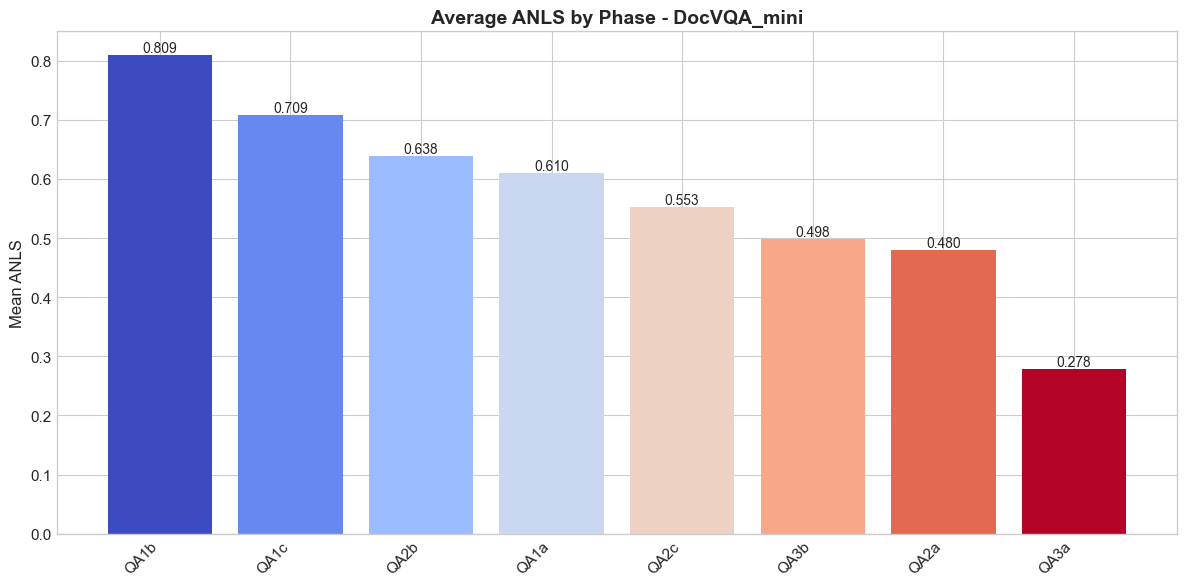

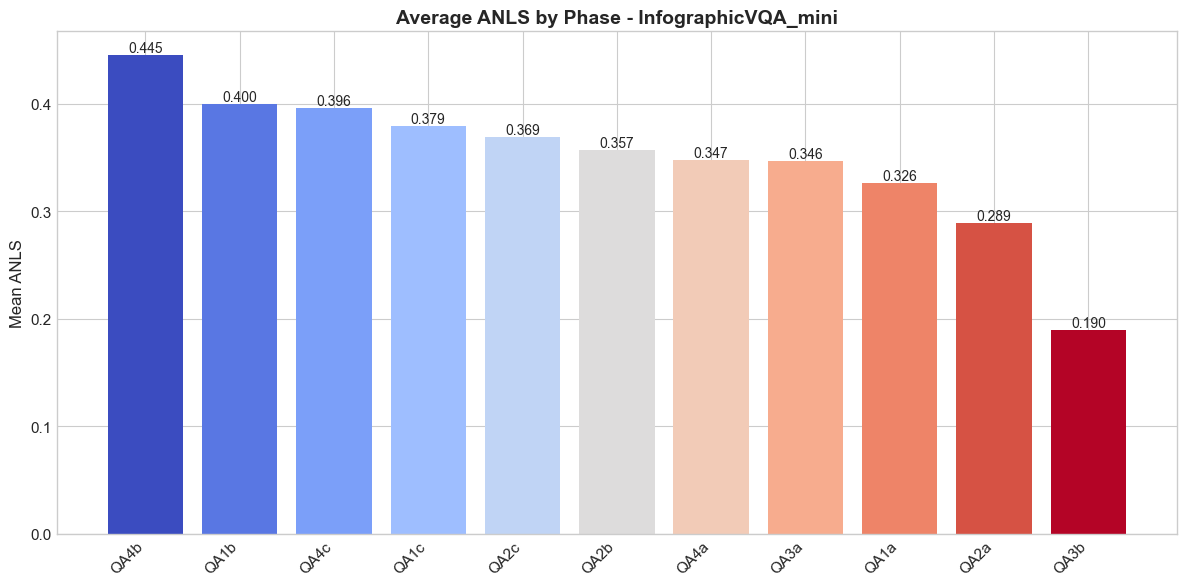

In [14]:
if not df_qa.empty and 'anls' in df_qa.columns:
    # ANLS by phase for each dataset
    for dataset in df_qa['dataset'].unique():
        dataset_data = df_qa[df_qa['dataset'] == dataset]
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        phase_anls = dataset_data.groupby('phase')['anls'].mean().sort_values(ascending=False)
        
        colors = plt.cm.coolwarm(np.linspace(0, 1, len(phase_anls)))
        bars = ax.bar(range(len(phase_anls)), phase_anls.values, color=colors)
        ax.set_xticks(range(len(phase_anls)))
        ax.set_xticklabels(phase_anls.index, rotation=45, ha='right')
        ax.set_ylabel('Mean ANLS', fontsize=12)
        ax.set_title(f'Average ANLS by Phase - {dataset}', fontsize=14, fontweight='bold')
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()
else:
    print("No ANLS data available for QA tasks")

## 5. Exact Match - QA Tasks

### 5.1 Exact Match by Dataset

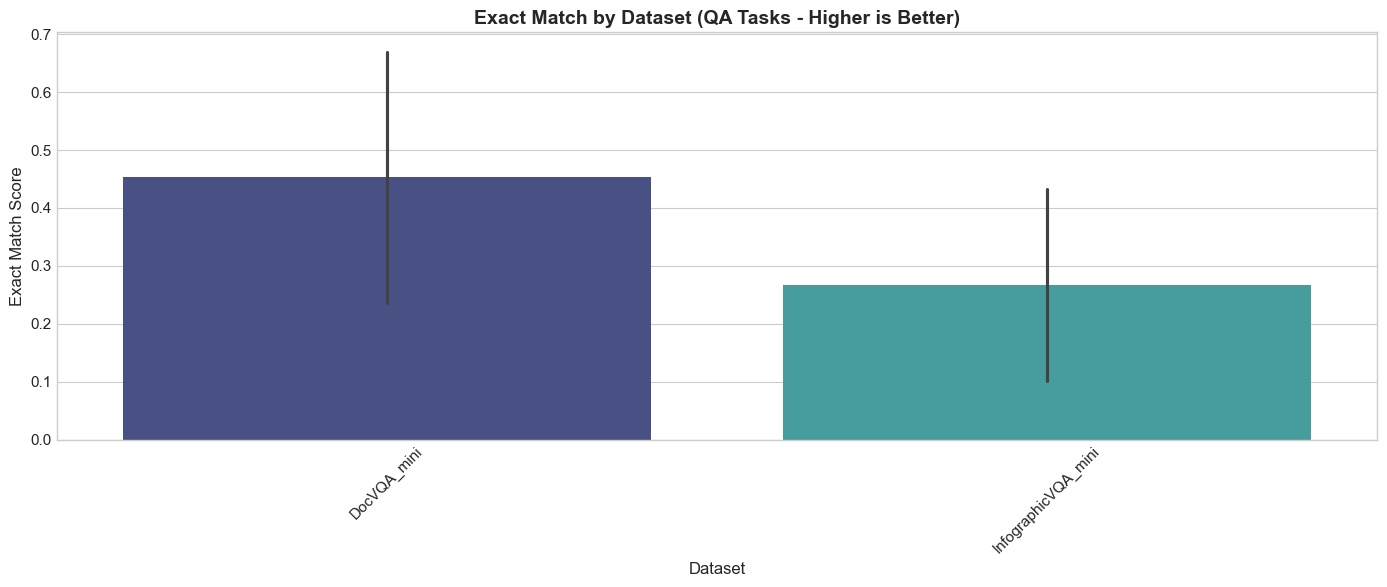


Exact Match Summary by Dataset:


,mean,median,std,min,max
dataset,,,,,
DocVQA_mini,0.4530,0.467,0.2166,0.0,0.776
InfographicVQA_mini,0.2675,0.266,0.1659,0.0,0.572


In [15]:
if not df_qa.empty and 'exact_match' in df_qa.columns:
    # EM by dataset
    fig, ax = plt.subplots(figsize=(14, 6))
    
    dataset_order = df_qa.groupby('dataset')['exact_match'].mean().sort_values(ascending=False).index
    
    sns.barplot(data=df_qa, x='dataset', y='exact_match', order=dataset_order, ax=ax, palette='mako', errorbar='sd')
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel('Exact Match Score', fontsize=12)
    ax.set_title('Exact Match by Dataset (QA Tasks - Higher is Better)', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    summary_em = df_qa.groupby('dataset')['exact_match'].agg(['mean', 'median', 'std', 'min', 'max']).round(4)
    print("\nExact Match Summary by Dataset:")
    display(summary_em)
else:
    print("No Exact Match data available")

### 5.2 Exact Match by Phase

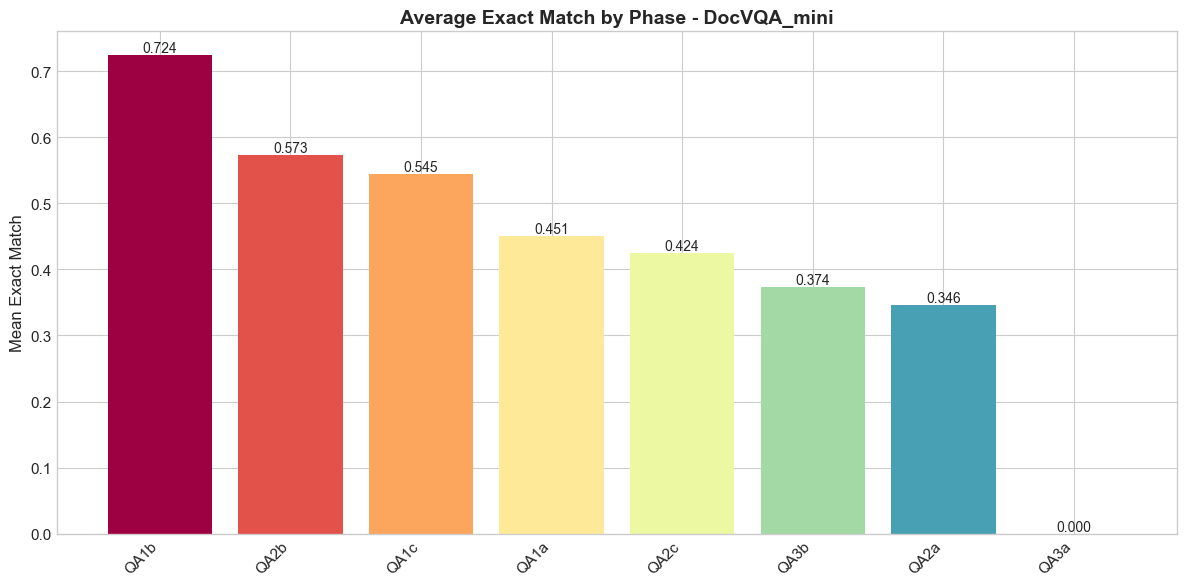

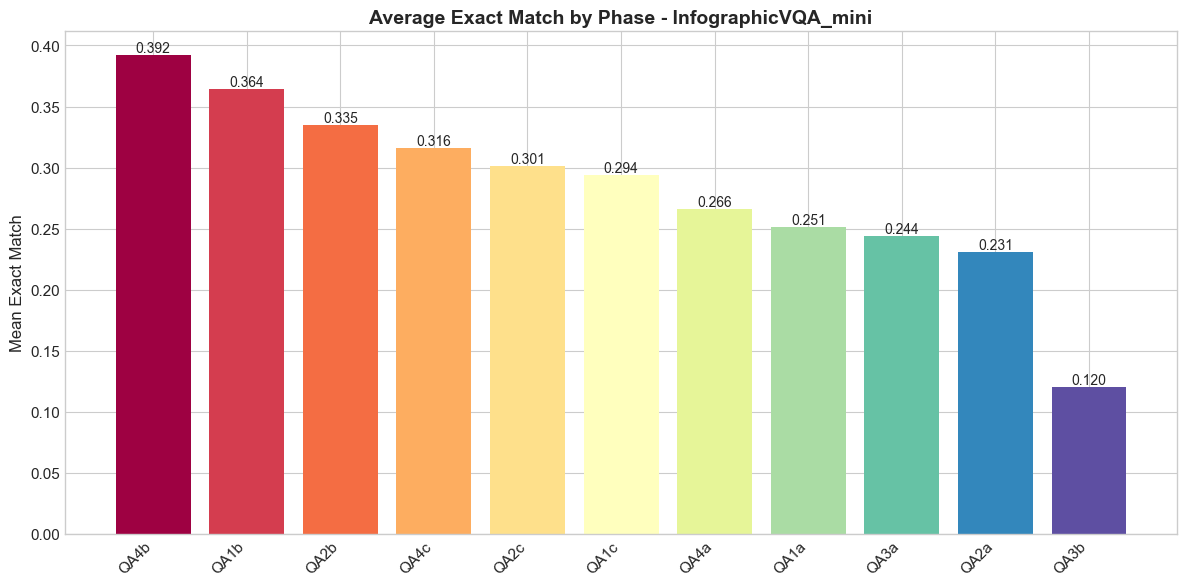

In [16]:
if not df_qa.empty and 'exact_match' in df_qa.columns:
    # EM by phase for each dataset
    for dataset in df_qa['dataset'].unique():
        dataset_data = df_qa[df_qa['dataset'] == dataset]
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        phase_em = dataset_data.groupby('phase')['exact_match'].mean().sort_values(ascending=False)
        
        colors = plt.cm.Spectral(np.linspace(0, 1, len(phase_em)))
        bars = ax.bar(range(len(phase_em)), phase_em.values, color=colors)
        ax.set_xticks(range(len(phase_em)))
        ax.set_xticklabels(phase_em.index, rotation=45, ha='right')
        ax.set_ylabel('Mean Exact Match', fontsize=12)
        ax.set_title(f'Average Exact Match by Phase - {dataset}', fontsize=14, fontweight='bold')
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10)
        
        plt.tight_layout()
        plt.show()
else:
    print("No Exact Match data available")

## 6. ANLS vs Exact Match Correlation (QA Tasks)

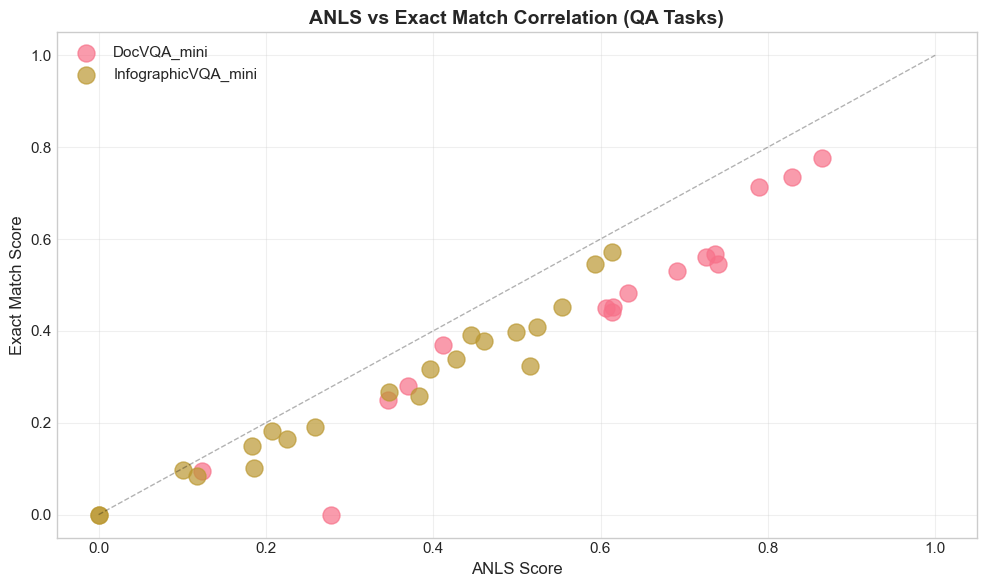


Correlation between ANLS and Exact Match: 0.9677


In [17]:
if not df_qa.empty and 'anls' in df_qa.columns and 'exact_match' in df_qa.columns:
    # ANLS vs EM scatter
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for dataset in df_qa['dataset'].unique():
        data = df_qa[df_qa['dataset'] == dataset]
        ax.scatter(data['anls'], data['exact_match'], label=dataset, alpha=0.7, s=150)
    
    ax.set_xlabel('ANLS Score', fontsize=12)
    ax.set_ylabel('Exact Match Score', fontsize=12)
    ax.set_title('ANLS vs Exact Match Correlation (QA Tasks)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add diagonal reference line
    lims = [0, 1]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    # Correlation coefficient
    corr = df_qa[['anls', 'exact_match']].corr().iloc[0, 1]
    print(f"\nCorrelation between ANLS and Exact Match: {corr:.4f}")
else:
    print("Cannot compute correlation - missing data")

## 7. Cross-Dataset Summary Statistics

In [18]:
print("="*80)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*80)

if not df_parsing.empty:
    print("\n" + "="*80)
    print("PARSING TASKS")
    print("="*80)
    
    print(f"\nTotal results: {len(df_parsing)}")
    print(f"Datasets: {df_parsing['dataset'].nunique()}")
    print(f"Phases: {df_parsing['phase'].nunique()}")
    print(f"Models: {df_parsing['model'].nunique()}")
    
    print("\nCER Statistics (across all datasets):")
    print(f"  Mean:   {df_parsing['cer_mean'].mean():.4f}")
    print(f"  Median: {df_parsing['cer_mean'].median():.4f}")
    print(f"  Std:    {df_parsing['cer_mean'].std():.4f}")
    print(f"  Min:    {df_parsing['cer_mean'].min():.4f}")
    print(f"  Max:    {df_parsing['cer_mean'].max():.4f}")
    
    print("\nWER Statistics (across all datasets):")
    print(f"  Mean:   {df_parsing['wer_mean'].mean():.4f}")
    print(f"  Median: {df_parsing['wer_mean'].median():.4f}")
    print(f"  Std:    {df_parsing['wer_mean'].std():.4f}")
    print(f"  Min:    {df_parsing['wer_mean'].min():.4f}")
    print(f"  Max:    {df_parsing['wer_mean'].max():.4f}")
    
    # Best model overall
    best_model = df_parsing.groupby('model')[['cer_mean', 'wer_mean']].mean().mean(axis=1).idxmin()
    print(f"\nBest overall model (lowest avg error): {best_model}")

if not df_qa.empty:
    print("\n" + "="*80)
    print("QA TASKS")
    print("="*80)
    
    print(f"\nTotal results: {len(df_qa)}")
    print(f"Datasets: {df_qa['dataset'].nunique()}")
    print(f"Phases: {df_qa['phase'].nunique()}")
    print(f"Models: {df_qa['model'].nunique()}")
    
    print("\nANLS Statistics (across all datasets):")
    print(f"  Mean:   {df_qa['anls'].mean():.4f}")
    print(f"  Median: {df_qa['anls'].median():.4f}")
    print(f"  Std:    {df_qa['anls'].std():.4f}")
    print(f"  Min:    {df_qa['anls'].min():.4f}")
    print(f"  Max:    {df_qa['anls'].max():.4f}")
    
    print("\nExact Match Statistics (across all datasets):")
    print(f"  Mean:   {df_qa['exact_match'].mean():.4f}")
    print(f"  Median: {df_qa['exact_match'].median():.4f}")
    print(f"  Std:    {df_qa['exact_match'].std():.4f}")
    print(f"  Min:    {df_qa['exact_match'].min():.4f}")
    print(f"  Max:    {df_qa['exact_match'].max():.4f}")
    
    # Best phase overall
    best_phase = df_qa.groupby('phase')['anls'].mean().idxmax()
    best_anls = df_qa.groupby('phase')['anls'].mean().max()
    print(f"\nBest overall phase (highest ANLS): {best_phase} (ANLS: {best_anls:.4f})")

COMPREHENSIVE SUMMARY STATISTICS

PARSING TASKS

Total results: 23
Datasets: 3
Phases: 5
Models: 6

CER Statistics (across all datasets):
  Mean:   1.0256
  Median: 0.5965
  Std:    1.2468
  Min:    0.0277
  Max:    5.0750

WER Statistics (across all datasets):
  Mean:   0.9885
  Median: 0.6628
  Std:    1.2064
  Min:    0.0360
  Max:    4.5249

Best overall model (lowest avg error): claude_sonnet

QA TASKS

Total results: 37
Datasets: 2
Phases: 11
Models: 7

ANLS Statistics (across all datasets):
  Mean:   0.4435
  Median: 0.4451
  Std:    0.2363
  Min:    0.0000
  Max:    0.8648

Exact Match Statistics (across all datasets):
  Mean:   0.3477
  Median: 0.3700
  Std:    0.2086
  Min:    0.0000
  Max:    0.7760

Best overall phase (highest ANLS): QA1b (ANLS: 0.6046)


---

# Summary & Key Findings

## Parsing Tasks (Part I)

### Best Performing Models:
- Review CER and WER metrics above to identify top performers per dataset
- Look for models with lowest error rates

### Dataset Difficulty Ranking:
- Compare mean CER/WER across datasets
- Higher values indicate more challenging datasets

## QA Tasks (Part II)

### Best Performing Approaches:
- Compare ANLS and Exact Match across phases
- Identify which pipeline (OCR→QA vs Direct VQA) performs better

### Key Insights:
- **ANLS** provides nuanced similarity scoring (fuzzy matching)
- **Exact Match** is stricter but clearer for evaluation (binary)
- **CER** (Character Error Rate): Character-level edit distance (lower is better)
- **WER** (Word Error Rate): Word-level edit distance (lower is better)
- Correlation between metrics indicates consistency

### Metric Interpretation:
- **High ANLS, Low CER/WER**: Model generates similar but not exact answers
- **High Exact Match**: Model generates precise, exact answers

---

## Recommendations

1. **For Parsing**: Prioritize models with lowest CER/WER on target domain
2. **For QA**: 
   - Use Exact Match for strict correctness requirements
   - Use ANLS for more lenient similarity-based evaluation
   - Use CER/WER for detailed text accuracy analysis
3. **Cross-Task**: Consider inference time vs accuracy tradeoffs

---

**Notebook Generated**: Comprehensive Evaluation Analysis  
**Data Source**: Consolidated CSVs in ../2_clean/  
**Datasets Analyzed**: 6 (4 Parsing + 2 QA)  
**Metrics Computed**: CER, WER (Parsing); ANLS, Exact Match (QA)